In [16]:
# Importing Necessary Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [17]:
# Loading the Dataset

df = pd.read_excel("/content/Uber A_B testing.xlsx")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [18]:
# Top Rows of Dataset
df.head()

,id,city_name,signup_os,signup_channel,signup_date,bgc_date,vehicle_added_date,vehicle_make,vehicle_model,vehicle_year,first_completed_date,experiment_group
0,1,Strark,ios web,Paid,2016-02-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,treatment
1,2,Strark,windows,Paid,1/21/16,NaN,NaN,NaN,NaN,NaN,NaN,treatment
2,3,Wrouver,windows,Organic,2016-11-01 00:00:00,2016-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN,treatment
3,4,Berton,android web,Referral,1/29/16,2016-03-02 00:00:00,2016-03-02 00:00:00,Toyota,Corolla,2016.0,2016-03-02 00:00:00,treatment
4,5,Strark,android web,Referral,2016-10-01 00:00:00,1/25/16,1/26/16,Hyundai,Sonata,2016.0,NaN,treatment


In [19]:
# Shape of Data
df.shape

(54681, 12)

In [20]:
# Columns
df.columns

Index(['id', 'city_name', 'signup_os', 'signup_channel', 'signup_date',
       'bgc_date', 'vehicle_added_date', 'vehicle_make', 'vehicle_model',
       'vehicle_year', 'first_completed_date', 'experiment_group'],
      dtype='object')

In [21]:
# Data Description

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,54681.0,NaN,NaN,NaN,27341.0,15785.189372,1.0,13671.0,27341.0,41011.0,54681.0
city_name,54681,3,Strark,29557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_os,47824,5,ios web,16632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_channel,54681,3,Paid,23938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,54681,30,2016-05-01 00:00:00,2489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bgc_date,32896,74,1/29/16,1125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_added_date,13134,78,1/26/16,377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_make,13223,46,Toyota,3219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_model,13223,368,Civic,689,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_year,13223.0,NaN,NaN,NaN,2010.568025,35.219184,0.0,2008.0,2013.0,2015.0,2017.0


In [22]:
# Checking Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54681 entries, 0 to 54680
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    54681 non-null  int64  
 1   city_name             54681 non-null  object 
 2   signup_os             47824 non-null  object 
 3   signup_channel        54681 non-null  object 
 4   signup_date           54681 non-null  object 
 5   bgc_date              32896 non-null  object 
 6   vehicle_added_date    13134 non-null  object 
 7   vehicle_make          13223 non-null  object 
 8   vehicle_model         13223 non-null  object 
 9   vehicle_year          13223 non-null  float64
 10  first_completed_date  6137 non-null   object 
 11  experiment_group      54681 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 5.0+ MB


In [23]:
# Checking for Duplicate Rows

duplicates = df.duplicated().sum()
print("Duplicate Records :",duplicates)

Duplicate Records : 0


In [24]:
# Checking for Duplicate Driver IDs

df['id'].duplicated().sum()

np.int64(0)

In [25]:
# Checking Missing Values

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean() * 100, 2)
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
first_completed_date,48544,88.78
vehicle_added_date,41547,75.98
vehicle_make,41458,75.82
vehicle_model,41458,75.82
vehicle_year,41458,75.82
bgc_date,21785,39.84
signup_os,6857,12.54
id,0,0.00
signup_channel,0,0.00
city_name,0,0.00


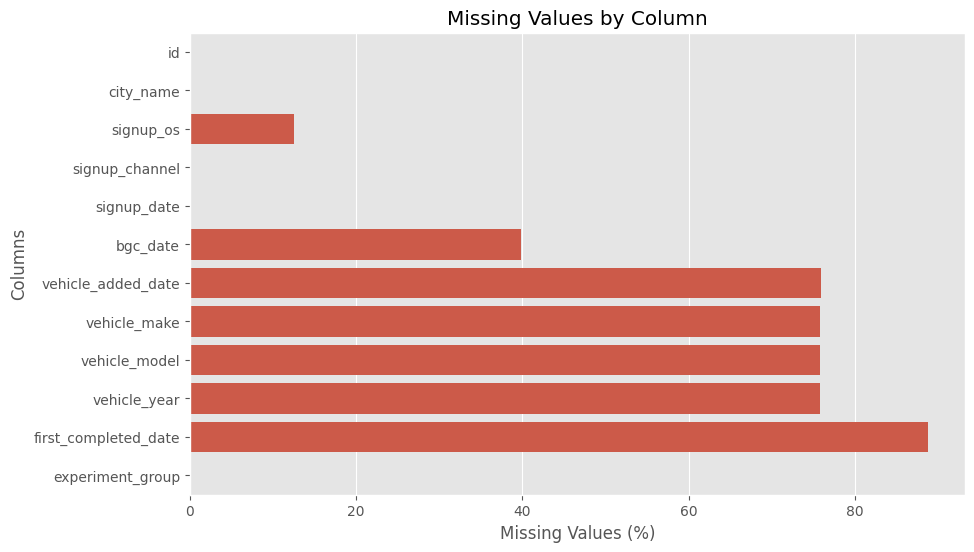

In [26]:
# Visualizing Missing Values

plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing["Percentage"],
    y=missing.index
)

plt.title("Missing Values by Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Columns")
plt.show()

In [27]:
# Checking Experiment Groups

df['experiment_group'].value_counts()

,count
experiment_group,
treatment,27467
control,27214


In [28]:
# Checking Signup Channels

df['signup_channel'].value_counts()

,count
signup_channel,
Paid,23938
Referral,17316
Organic,13427


In [29]:
# Checking City Distribution

df['city_name'].value_counts()

,count
city_name,
Strark,29557
Berton,20117
Wrouver,5007


In [30]:
# Checking Signup Operating System

df['signup_os'].value_counts(dropna=False)

,count
signup_os,
ios web,16632
android web,14944
NaN,6857
windows,6776
mac,5824
other,3648


In [31]:
# Convert Date Columns

date_columns = [
    "signup_date",
    "bgc_date",
    "vehicle_added_date",
    "first_completed_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54681 entries, 0 to 54680
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    54681 non-null  int64         
 1   city_name             54681 non-null  object        
 2   signup_os             47824 non-null  object        
 3   signup_channel        54681 non-null  object        
 4   signup_date           54681 non-null  datetime64[ns]
 5   bgc_date              32896 non-null  datetime64[ns]
 6   vehicle_added_date    13134 non-null  datetime64[ns]
 7   vehicle_make          13223 non-null  object        
 8   vehicle_model         13223 non-null  object        
 9   vehicle_year          13223 non-null  float64       
 10  first_completed_date  6137 non-null   datetime64[ns]
 11  experiment_group      54681 non-null  object        
dtypes: datetime64[ns](4), float64(1), int64(1), object(6)
memory usage: 5.0+ M

In [32]:
# Vehicle Age

current_year = 2026

df["vehicle_age"] = current_year - df["vehicle_year"]

In [33]:
# Signup to BGC

df["signup_to_bgc"] = (
    df["bgc_date"] - df["signup_date"]
).dt.days

In [34]:
# BGC to Vehicle

df["bgc_to_vehicle"]=(df["vehicle_added_date"]-
                      df["bgc_date"]
).dt.days

In [35]:
# Vehicle to First Ride
df["vehicle_to_firstride"]=(df["first_completed_date"]-
                            df["vehicle_added_date"]
).dt.days

In [36]:
# Signup to First Ride
df["signup_to_firstride"]=(df["first_completed_date"]-
                           df["signup_date"]
).dt.days

In [37]:
# Driver Activated (this creates the binary variable)

df["completed_first_ride"]=np.where(
    df["first_completed_date"].isna(),
    0,
    1
)

In [38]:
# Month

df["signup_month"] = df["signup_date"].dt.month_name()

In [39]:
# Weekday

df["signup_weekday"]=df["signup_date"].dt.day_name()

In [40]:
# Year

df["signup_year"]=df["signup_date"].dt.year

In [41]:
# Check New Dataset

df.head()

,id,city_name,signup_os,signup_channel,signup_date,bgc_date,vehicle_added_date,vehicle_make,vehicle_model,vehicle_year,first_completed_date,experiment_group,vehicle_age,signup_to_bgc,bgc_to_vehicle,vehicle_to_firstride,signup_to_firstride,completed_first_ride,signup_month,signup_weekday,signup_year
0,1,Strark,ios web,Paid,2016-02-01,NaT,NaT,NaN,NaN,NaN,NaT,treatment,NaN,NaN,NaN,NaN,NaN,0,February,Monday,2016
1,2,Strark,windows,Paid,2016-01-21,NaT,NaT,NaN,NaN,NaN,NaT,treatment,NaN,NaN,NaN,NaN,NaN,0,January,Thursday,2016
2,3,Wrouver,windows,Organic,2016-11-01,2016-11-01,NaT,NaN,NaN,NaN,NaT,treatment,NaN,0.0,NaN,NaN,NaN,0,November,Tuesday,2016
3,4,Berton,android web,Referral,2016-01-29,2016-03-02,2016-03-02,Toyota,Corolla,2016.0,2016-03-02,treatment,10.0,33.0,0.0,0.0,33.0,1,January,Friday,2016
4,5,Strark,android web,Referral,2016-10-01,2016-01-25,2016-01-26,Hyundai,Sonata,2016.0,NaT,treatment,10.0,-250.0,1.0,NaN,NaN,0,October,Saturday,2016


**Handling Missing Values**

In [42]:
# Impute 'signup_os' with the mode
df['signup_os'].fillna(df['signup_os'].mode()[0], inplace=True)

# Fill NaN values in duration columns with 0, assuming 0 days if the event hasn't occurred
duration_cols = [
    'vehicle_age',
    'signup_to_bgc',
    'bgc_to_vehicle',
    'vehicle_to_firstride',
    'signup_to_firstride'
]
for col in duration_cols:
    df[col].fillna(0, inplace=True)

# Fill NaN values for vehicle details with 'Unknown' or 0
df['vehicle_make'].fillna('Unknown', inplace=True)
df['vehicle_model'].fillna('Unknown', inplace=True)
df['vehicle_year'].fillna(0, inplace=True)

# Display the info and head to verify changes
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54681 entries, 0 to 54680
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    54681 non-null  int64         
 1   city_name             54681 non-null  object        
 2   signup_os             54681 non-null  object        
 3   signup_channel        54681 non-null  object        
 4   signup_date           54681 non-null  datetime64[ns]
 5   bgc_date              32896 non-null  datetime64[ns]
 6   vehicle_added_date    13134 non-null  datetime64[ns]
 7   vehicle_make          54681 non-null  object        
 8   vehicle_model         54681 non-null  object        
 9   vehicle_year          54681 non-null  float64       
 10  first_completed_date  6137 non-null   datetime64[ns]
 11  experiment_group      54681 non-null  object        
 12  vehicle_age           54681 non-null  float64       
 13  signup_to_bgc   

,id,city_name,signup_os,signup_channel,signup_date,bgc_date,vehicle_added_date,vehicle_make,vehicle_model,vehicle_year,first_completed_date,experiment_group,vehicle_age,signup_to_bgc,bgc_to_vehicle,vehicle_to_firstride,signup_to_firstride,completed_first_ride,signup_month,signup_weekday,signup_year
0,1,Strark,ios web,Paid,2016-02-01,NaT,NaT,Unknown,Unknown,0.0,NaT,treatment,0.0,0.0,0.0,0.0,0.0,0,February,Monday,2016
1,2,Strark,windows,Paid,2016-01-21,NaT,NaT,Unknown,Unknown,0.0,NaT,treatment,0.0,0.0,0.0,0.0,0.0,0,January,Thursday,2016
2,3,Wrouver,windows,Organic,2016-11-01,2016-11-01,NaT,Unknown,Unknown,0.0,NaT,treatment,0.0,0.0,0.0,0.0,0.0,0,November,Tuesday,2016
3,4,Berton,android web,Referral,2016-01-29,2016-03-02,2016-03-02,Toyota,Corolla,2016.0,2016-03-02,treatment,10.0,33.0,0.0,0.0,33.0,1,January,Friday,2016
4,5,Strark,android web,Referral,2016-10-01,2016-01-25,2016-01-26,Hyundai,Sonata,2016.0,NaT,treatment,10.0,-250.0,1.0,0.0,0.0,0,October,Saturday,2016


In [43]:
# Updated Dataset Description
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,54681.0,27341.0,1.0,13671.0,27341.0,41011.0,54681.0,15785.189372
signup_date,54681,2016-03-22 13:58:15.320129536,2016-01-01 00:00:00,2016-01-20 00:00:00,2016-01-27 00:00:00,2016-05-01 00:00:00,2016-12-01 00:00:00,NaN
bgc_date,32896,2016-03-21 05:37:22.120622336,2016-01-01 00:00:00,2016-01-21 00:00:00,2016-01-29 00:00:00,2016-05-01 00:00:00,2016-12-03 00:00:00,NaN
vehicle_added_date,13134,2016-03-22 17:49:38.346276864,2016-01-01 00:00:00,2016-01-23 00:00:00,2016-02-14 00:00:00,2016-04-02 00:00:00,2016-12-03 00:00:00,NaN
vehicle_year,54681.0,486.197052,0.0,0.0,0.0,0.0,2017.0,861.079649
first_completed_date,6137,2016-03-22 05:58:32.009124864,2016-01-02 00:00:00,2016-01-22 00:00:00,2016-01-30 00:00:00,2016-05-02 00:00:00,2016-12-02 00:00:00,NaN
vehicle_age,54681.0,3.731772,0.0,0.0,0.0,0.0,2026.0,18.536406
signup_to_bgc,54681.0,-1.241967,-334.0,0.0,0.0,7.0,336.0,93.767722
bgc_to_vehicle,54681.0,0.008595,-334.0,0.0,0.0,0.0,335.0,52.701147
vehicle_to_firstride,54681.0,0.03215,-323.0,0.0,0.0,0.0,335.0,38.306531


In [44]:
# Categorical Variables Summary

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("\n" + "=" * 60)
    print(f"{col.upper()}")
    print("=" * 60)

    summary = pd.DataFrame({
        "Count": df[col].value_counts(dropna=False),
        "Percentage": df[col].value_counts(normalize=True, dropna=False).mul(100).round(2)
    })

    print(summary)


CITY_NAME
           Count  Percentage
city_name                   
Strark     29557       54.05
Berton     20117       36.79
Wrouver     5007        9.16

SIGNUP_OS
             Count  Percentage
signup_os                     
ios web      23489       42.96
android web  14944       27.33
windows       6776       12.39
mac           5824       10.65
other         3648        6.67

SIGNUP_CHANNEL
                Count  Percentage
signup_channel                   
Paid            23938       43.78
Referral        17316       31.67
Organic         13427       24.56

VEHICLE_MAKE
               Count  Percentage
vehicle_make                    
Unknown        41458       75.82
Toyota          3219        5.89
Honda           1845        3.37
Nissan          1311        2.40
Ford             778        1.42
Hyundai          677        1.24
Chevrolet        665        1.22
Kia              584        1.07
Volkswagen       503        0.92
Dodge            393        0.72
Mercedes-Benz    348

**Exploratory Data Analysis**

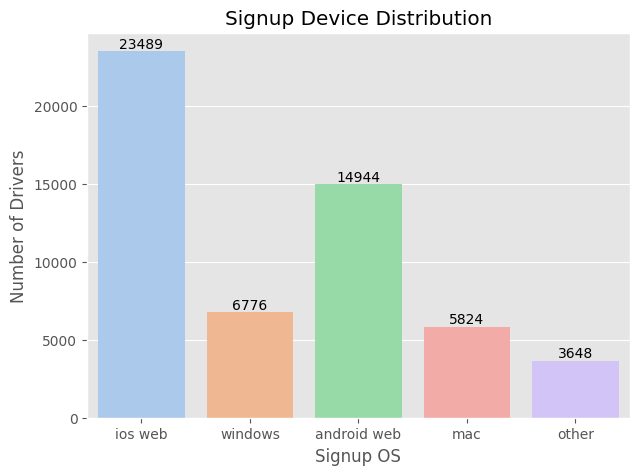

In [45]:
# Signup OS Distribution

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x="signup_os",
    data=df,
    palette="pastel"
)

plt.title("Signup Device Distribution")
plt.xlabel("Signup OS")
plt.ylabel("Number of Drivers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

**Insights**

The most preferred signup platforms are iOS and Android Web.

Onboarding Optimization Strategies
Mobile Web Enhancements


*   Responsive Layouts: Ensure all signup forms are optimized to display properly across mobile screen sizes.

*   Smart Defaults: Use browser permissions to auto-fill information such as location and language where appropriate.
*   Social Authentication: Provide one-click signup options through Google, Apple, or phone number authentication.


*   Progress Trackers: Use visual progress indicators to show users how many steps remain in the signup process.

Technical Performance


*  Page Speed: Compress images and optimize scripts to reduce mobile loading times.
*   Form Validation: Implement real-time error checking before a user submits data.
*   File Uploads: Streamline document submission (e.g., licenses) with mobile camera integration.








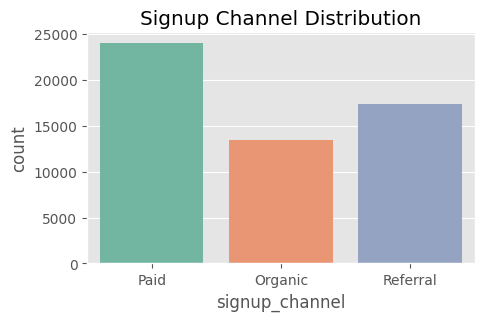

In [46]:
# Signup Channel

plt.figure(figsize=(5,3))

sns.countplot(
    x="signup_channel",
    data=df,
    palette="Set2"
)

plt.title("Signup Channel Distribution")

plt.show()

**Insights**



*   Paid Channel: This is the largest acquisition source, generating approximately 24,000 driver signups.
*   Referral Channel: This is the second-largest source, contributing approximately 17,300 driver signups.

*   Organic Channel: This channel generated the fewest signups, with approximately 13,400 drivers.

*   Offline Channel: This channel is entirely missing from the chart, indicating zero tracked data or a complete gap in offline recruitment efforts.

Strategy Takeaways


*   Paid Dominance: Paid marketing is currently the primary driver acquisition channel, so its performance and cost-effectiveness should be monitored closely.

*   Referral Opportunity: Referral is the second-largest acquisition source, indicating a strong opportunity to strengthen referral programs and encourage word-of-mouth recruitment.
*   Organic Growth: Since Organic generates the lowest signup volume, Uber could explore ways to improve organic acquisition through better search visibility, content, and brand awareness.







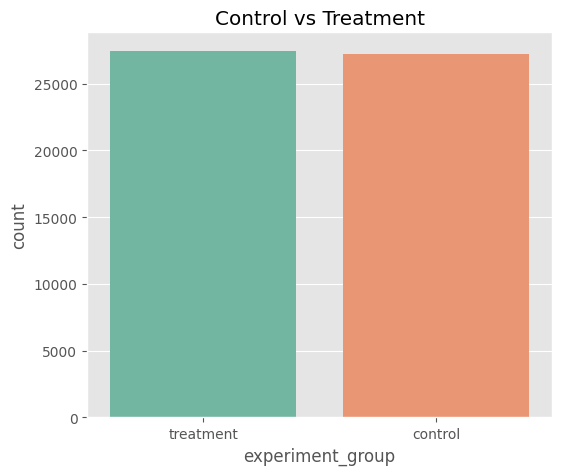

In [47]:
# Experiment Group Distribution

plt.figure(figsize=(6,5))

sns.countplot(
    x="experiment_group",
    data=df,
    palette="Set2"
)

plt.title("Control vs Treatment")

plt.show()

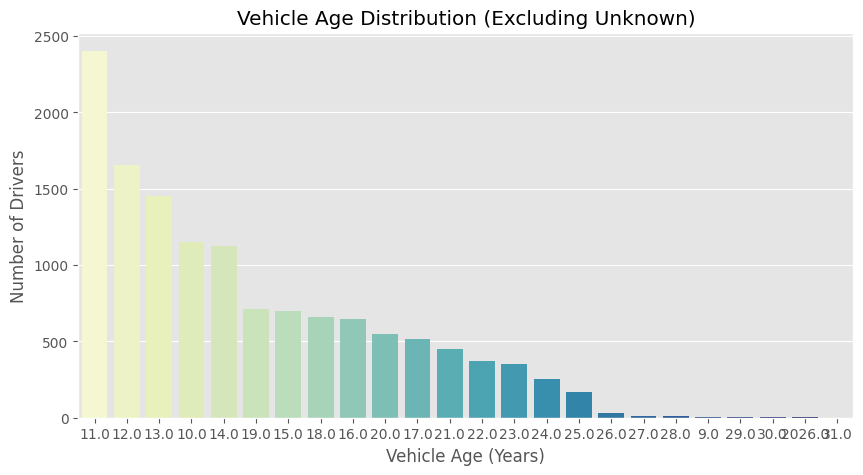

In [48]:
# Vehicle Age Distribution

plt.figure(figsize=(10,5))

# Filter out entries where vehicle_age is 0 (representing unknown values)
df_known_age = df[df["vehicle_age"] != 0]

sns.countplot(
    x="vehicle_age",
    data=df_known_age,
    palette="YlGnBu",
    order=df_known_age["vehicle_age"].value_counts().index
)

plt.title("Vehicle Age Distribution (Excluding Unknown)")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Number of Drivers")

plt.show()

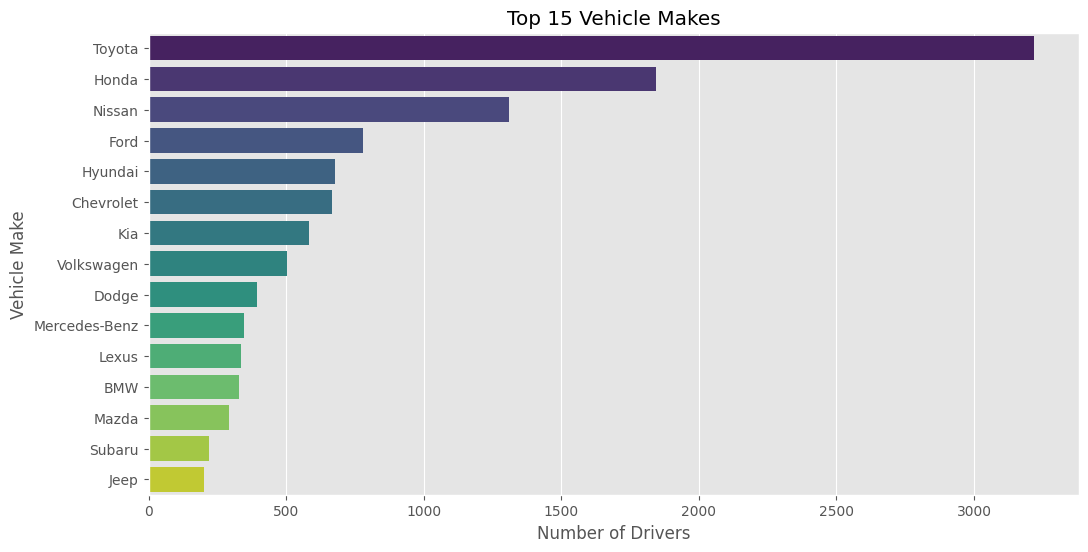

In [101]:
# Vehicle Make

plt.figure(figsize=(12,6))

vehicle_make_counts = (
    df[df["vehicle_make"] != "Unknown"]["vehicle_make"]
    .value_counts()
    .head(15)
)

sns.barplot(
    x=vehicle_make_counts.values,
    y=vehicle_make_counts.index,
    palette="viridis"
)

plt.title("Top 15 Vehicle Makes")
plt.xlabel("Number of Drivers")
plt.ylabel("Vehicle Make")

plt.show()
plt.show()

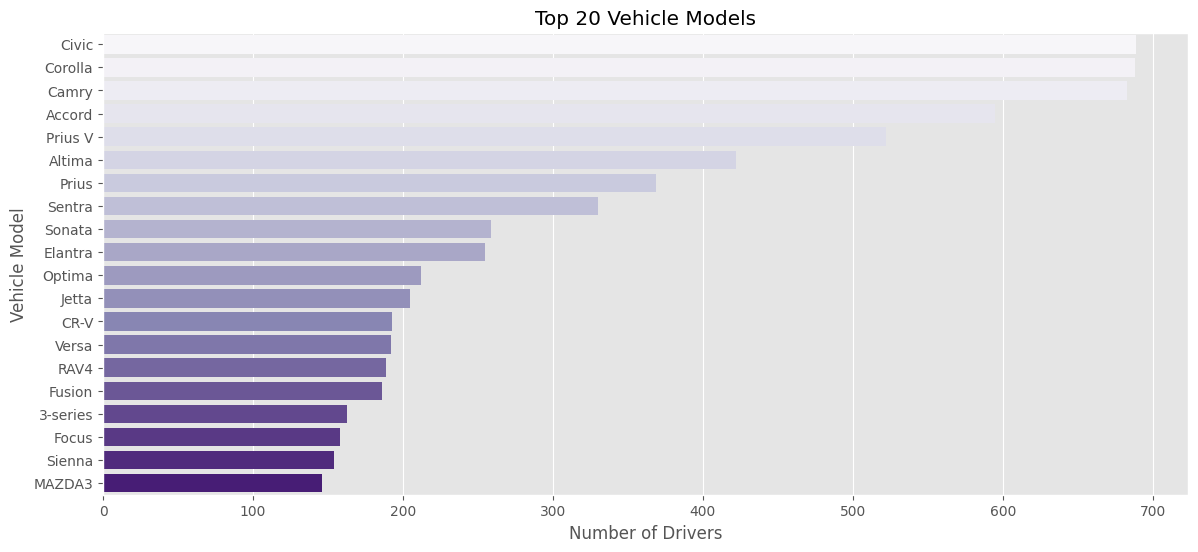

In [99]:
# Vehicle Model

plt.figure(figsize=(14,6))

vehicle_model_counts = (
    df[df["vehicle_model"] != "Unknown"]["vehicle_model"]
    .value_counts()
    .head(20)
)

sns.barplot(
    x=vehicle_model_counts.values,
    y=vehicle_model_counts.index,
    palette="Purples"
)

plt.title("Top 20 Vehicle Models")
plt.xlabel("Number of Drivers")
plt.ylabel("Vehicle Model")

plt.show()

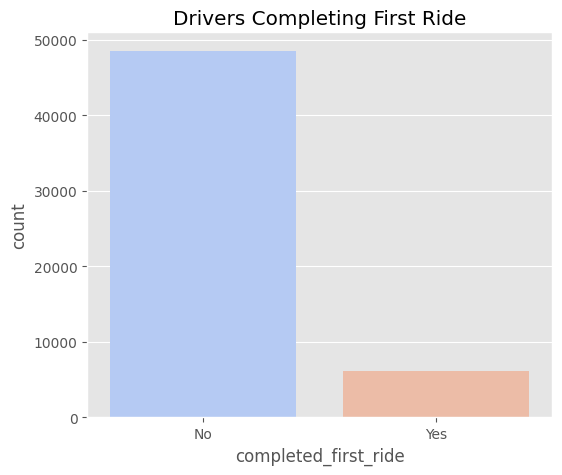

In [51]:
# Driver Activation

plt.figure(figsize=(6,5))

sns.countplot(
    x="completed_first_ride",
    data=df,
    palette="coolwarm"
)

plt.title("Drivers Completing First Ride")
plt.xticks([0,1],["No","Yes"])

plt.show()

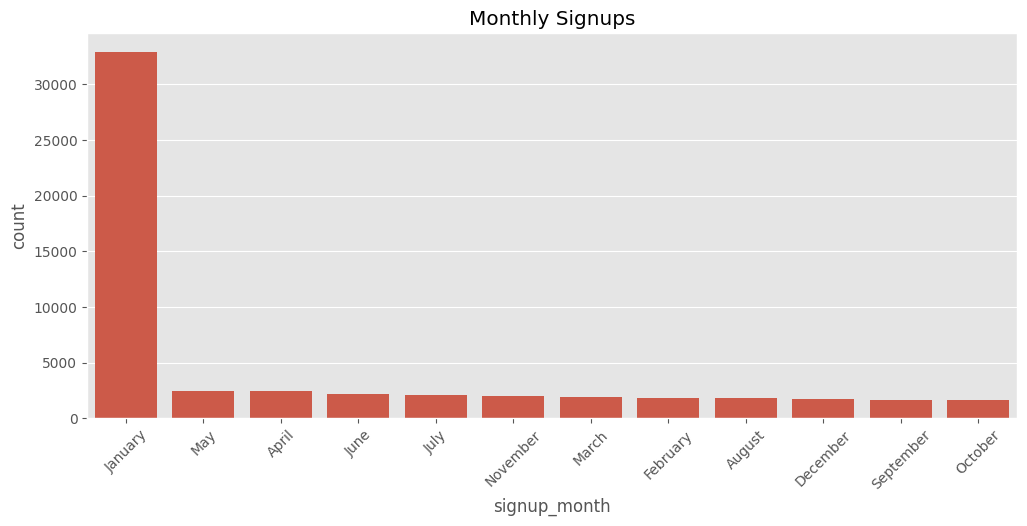

In [52]:
# Signup Month Trend

plt.figure(figsize=(12,5))

sns.countplot(
    x="signup_month",
    data=df,
    order=df["signup_month"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Monthly Signups")

plt.show()

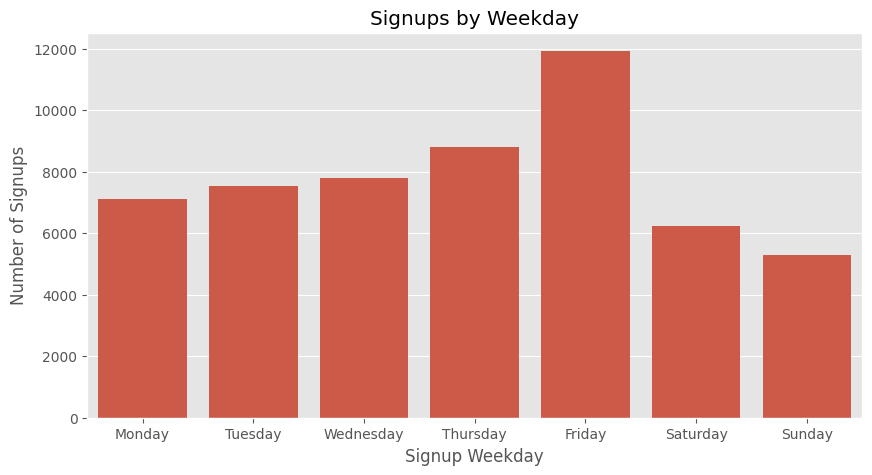

In [53]:
# Signup Weekday

plt.figure(figsize=(10,5))

sns.countplot(
    x="signup_weekday",
    data=df,
    order=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]
)

plt.title("Signups by Weekday")
plt.xlabel("Signup Weekday")
plt.ylabel("Number of Signups")

plt.show()

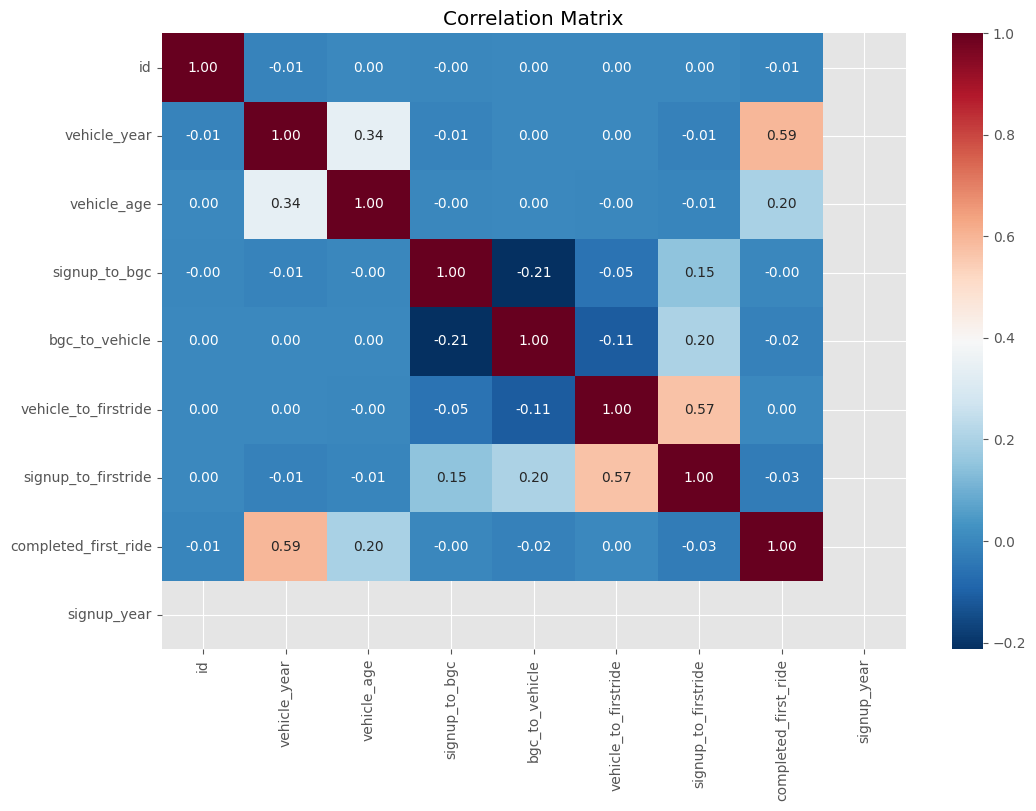

In [54]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

**Statistical Analysis & A/B Testing**

Driver Activation Rate = Drivers Completing Their First Ride / Total Drivers Signed Up

Why?

The redesigned Partner App aims to improve the onboarding experience. The most meaningful measure of success is whether a new driver becomes an active driver by completing their first trip.

In [55]:
#Activation Rate

activation_rate = df["completed_first_ride"].mean()*100

print(f"Driver Activation Rate : {activation_rate:.2f}%")

Driver Activation Rate : 11.22%


In [56]:
# Secondary Metrics

print("Average Signup → BGC Time")
print(df["signup_to_bgc"].mean())

print()

print("Average BGC → Vehicle Upload")
print(df["bgc_to_vehicle"].mean())

print()

print("Average Signup → First Ride")
print(df["signup_to_firstride"].mean())

Average Signup → BGC Time
-1.2419670452259468

Average BGC → Vehicle Upload
0.008595307327956695

Average Signup → First Ride
-0.5137433477807648


Business Interpretation

These metrics measure onboarding efficiency.

A successful redesign should

reduce onboarding time
increase activation
reduce friction

Statistical Test

Does Signup Channel Affect First Ride Completion?

Hypothesis

Null Hypothesis: Driver activation is independent of signup channel.

Alternative: Driver activation depends on signup channel.

In [57]:
# Contingency Table

table = pd.crosstab(
    df["signup_channel"],
    df["completed_first_ride"]
)

table

completed_first_ride,0,1
signup_channel,,
Organic,12217,1210
Paid,22456,1482
Referral,13871,3445


In [58]:
# Chi-Square Test

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print("Chi Square :", chi2)
print("P Value :", p)
print("Degree of Freedom :", dof)

Chi Square : 1981.1865096042625
P Value : 0.0
Degree of Freedom : 2


In [59]:
# Decision

alpha = 0.05

print(f"P-value: {p:.4f}")

if p < alpha:
    print("Reject H0: Signup channel is significantly associated with first-ride completion.")
else:
    print("Fail to reject H0: There is insufficient evidence of an association between signup channel and first-ride completion.")

P-value: 0.0000
Reject H0: Signup channel is significantly associated with first-ride completion.


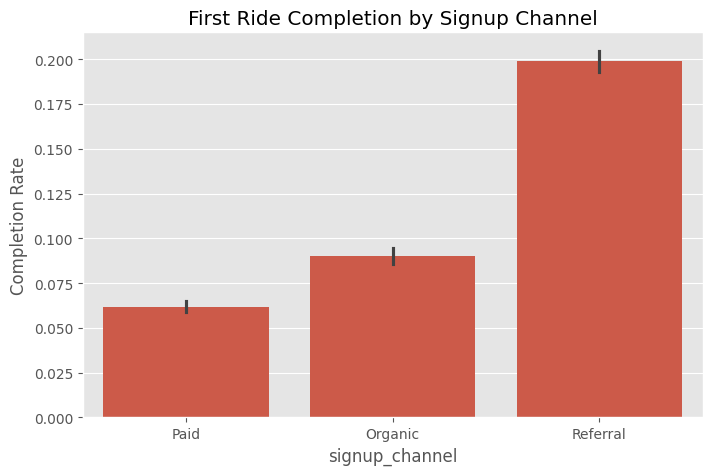

In [60]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="signup_channel",
    y="completed_first_ride",
    data=df,
    estimator=np.mean
)

plt.ylabel("Completion Rate")

plt.title("First Ride Completion by Signup Channel")

plt.show()

**A/B Testing Compare Treatment vs Control**

In [61]:
# Driver Activation Rate by Experiment Group

activation = df.groupby(
    "experiment_group"
)["completed_first_ride"].mean() * 100

activation

,completed_first_ride
experiment_group,
control,11.207467
treatment,11.238941


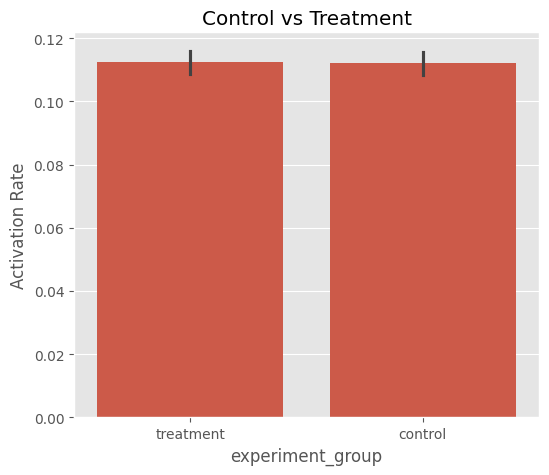

In [62]:
# Driver Activation Rate by Experiment Group (Visulisation)

plt.figure(figsize=(6,5))

sns.barplot(
    x="experiment_group",
    y="completed_first_ride",
    data=df,
    estimator=np.mean
)

plt.ylabel("Activation Rate")
plt.title("Control vs Treatment")

plt.show()

In [63]:
# Two-Proportion Z-Test

from statsmodels.stats.proportion import proportions_ztest

success = df.groupby(
    "experiment_group"
)["completed_first_ride"].sum()

total = df.groupby(
    "experiment_group"
)["completed_first_ride"].count()

stat,p = proportions_ztest(
    success,
    total
)

print(stat)

print(p)

-0.11658252025310642
0.9071908900738574


In [64]:
# Decision

alpha = 0.05

if p < alpha:
    print("Reject H0: There is a statistically significant difference in activation rates between Treatment and Control.")
else:
    print("Fail to reject H0: There is no statistically significant difference in activation rates between Treatment and Control.")

Fail to reject H0: There is no statistically significant difference in activation rates between Treatment and Control.


In [65]:
# Prepare Vehicle Age Groups by City

groups = []

cities = df["city_name"].dropna().unique()

for city in cities:

    groups.append(
        df[df["city_name"] == city]["vehicle_age"].dropna()
    )

In [66]:
# ANOVA

from scipy.stats import f_oneway

F, p = f_oneway(*groups)

print(F)
print(p)

5.162228461532029
0.005731711226666794


In [67]:
# ANOVA Decision

alpha = 0.05

if p < alpha:
    print("Reject H0: Vehicle age differs significantly across cities.")
else:
    print("Fail to reject H0: No significant difference in vehicle age across cities.")

Reject H0: Vehicle age differs significantly across cities.


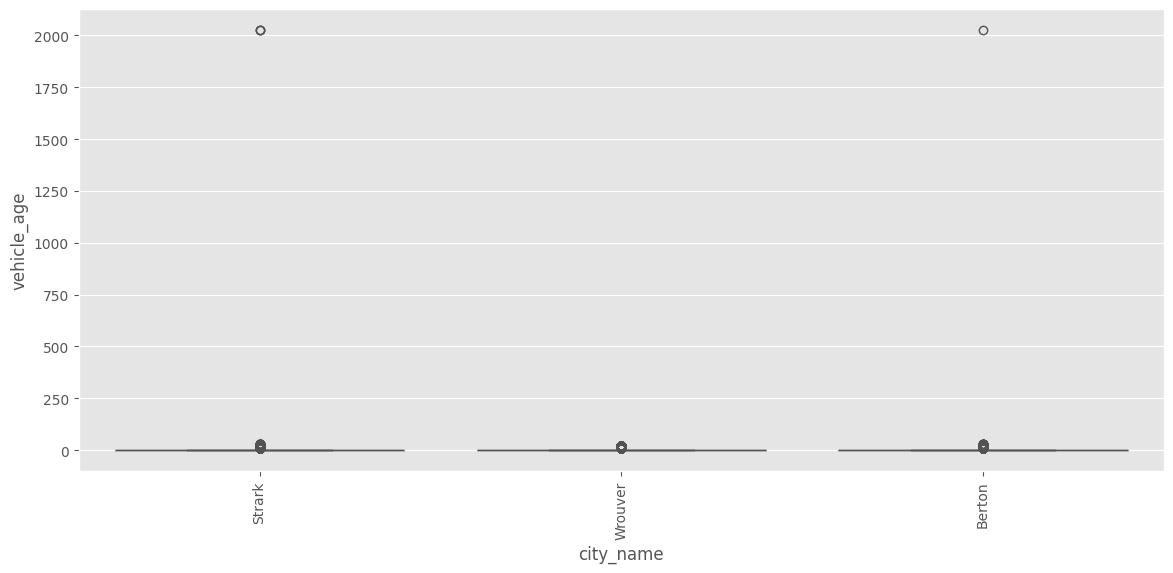

In [68]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x="city_name",
    y="vehicle_age",
    data=df
)

plt.xticks(rotation=90)

plt.show()

In [69]:
# Demographic Factors

# Average activation by city

city = df.groupby(
    "city_name"
)["completed_first_ride"].mean().sort_values(ascending=False)

city.head(10)

,completed_first_ride
city_name,
Berton,0.121141
Strark,0.109585
Wrouver,0.092071


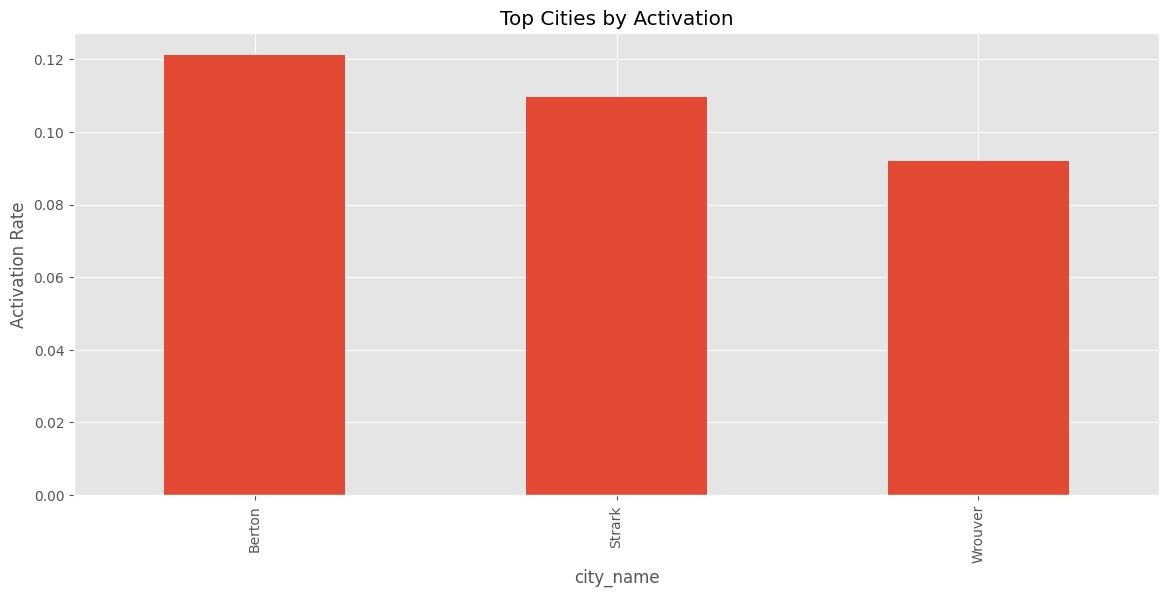

In [70]:
#Visualization

plt.figure(figsize=(14,6))

city.head(15).plot(kind="bar")

plt.ylabel("Activation Rate")

plt.title("Top Cities by Activation")

plt.show()

In [71]:
#Vehicle Make

vehicle=df.groupby(
    "vehicle_make"
)["completed_first_ride"].mean().sort_values(ascending=False)

vehicle.head(15)

,completed_first_ride
vehicle_make,
Oldsmobile,1.000000
Mercury,0.555556
Maserati,0.500000
Isuzu,0.500000
Suzuki,0.500000
Scion,0.481707
Lexus,0.480597
Buick,0.478261
Toyota,0.476856


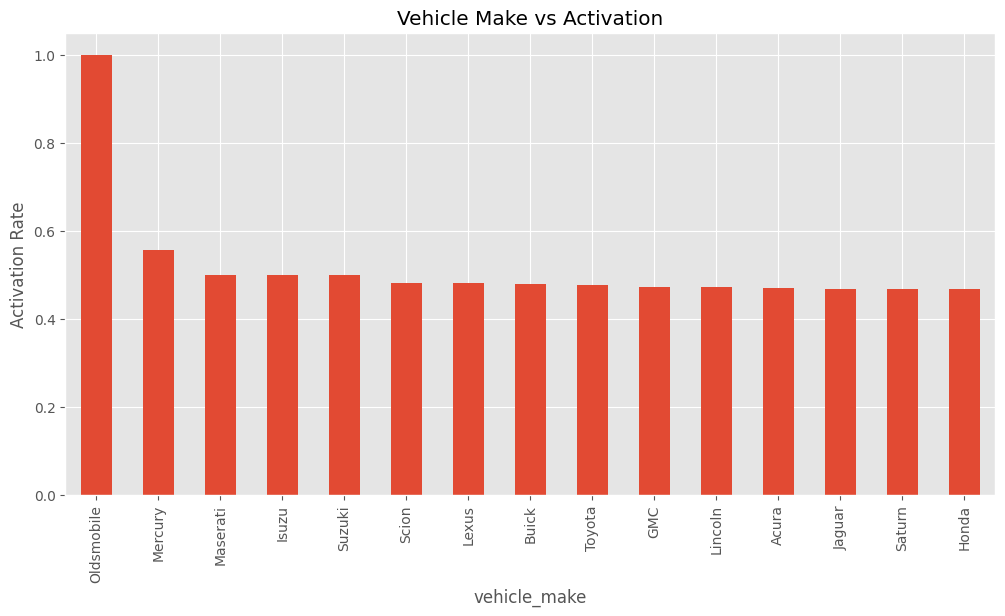

In [72]:
#Visualization

plt.figure(figsize=(12,6))

vehicle.head(15).plot(kind="bar")

plt.ylabel("Activation Rate")

plt.title("Vehicle Make vs Activation")

plt.show()

In [73]:
# Convert all vehicle models to string to prevent comparison errors
df["vehicle_model"] = df["vehicle_model"].astype(str)

# Calculate activation rate by model
model = df.groupby("vehicle_model")["completed_first_ride"].mean().sort_values(ascending=False)
model.head(20)

,completed_first_ride
vehicle_model,
A8,1.000000
Vitara,1.000000
Allroad,1.000000
Amanti,1.000000
Venture,1.000000
Echo,1.000000
Commander,1.000000
Silverado 1500 4door,1.000000
Bravada,1.000000


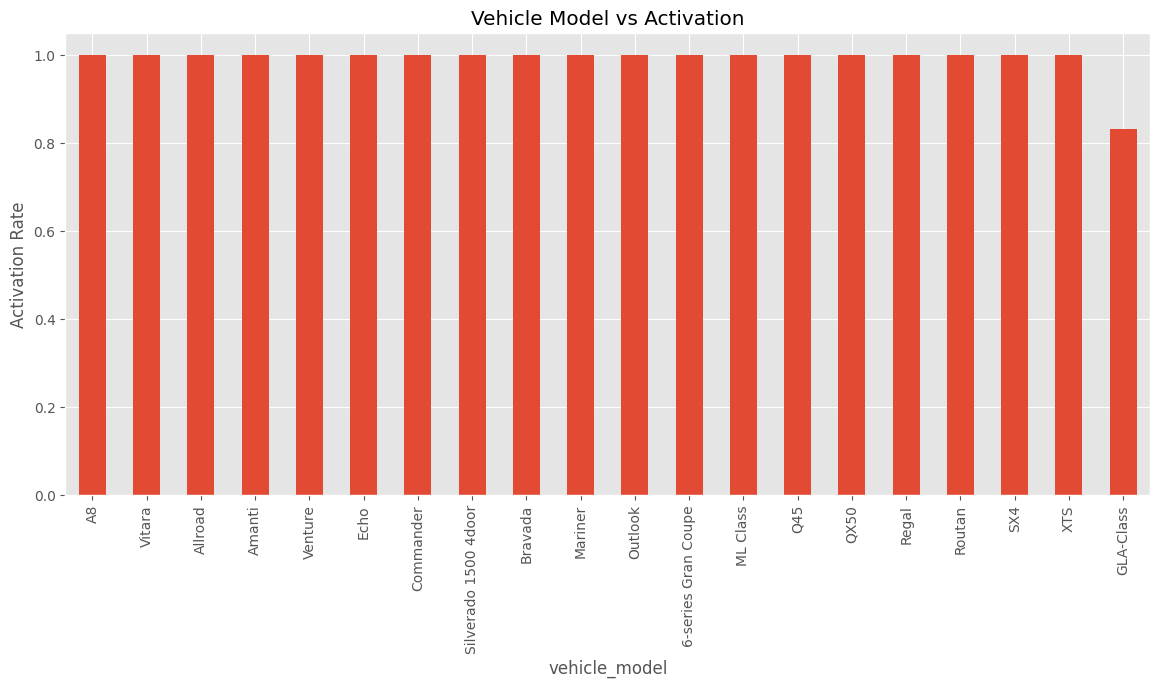

In [74]:

plt.figure(figsize=(14,6))

model.head(20).plot(kind="bar")

plt.ylabel("Activation Rate")

plt.title("Vehicle Model vs Activation")

plt.show()

<Axes: xlabel='experiment_group', ylabel='completed_first_ride'>

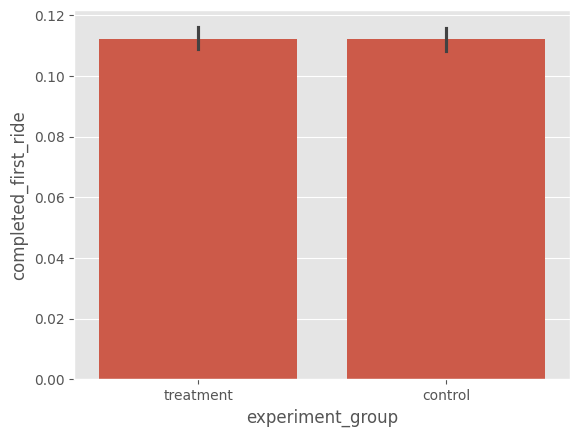

In [75]:
sns.barplot(
    x="experiment_group",
    y="completed_first_ride",
    data=df,
    estimator=np.mean
)

In [76]:
# Correlation Analysis

# Question -> Is signup → background check correlated with
# background check → vehicle upload?

# Pearson Correlation

from scipy.stats import pearsonr

temp = df[
    ["signup_to_bgc", "bgc_to_vehicle"]
].dropna()

corr, p = pearsonr(
    temp["signup_to_bgc"],
    temp["bgc_to_vehicle"]
)

print(corr)
print(p)

-0.21329570217855426
0.0


In [77]:
# Spearman Correlation

from scipy.stats import spearmanr

corr, p = spearmanr(
    temp["signup_to_bgc"],
    temp["bgc_to_vehicle"]
)

print(corr)
print(p)

-0.07886372322879236
3.613040823063e-76


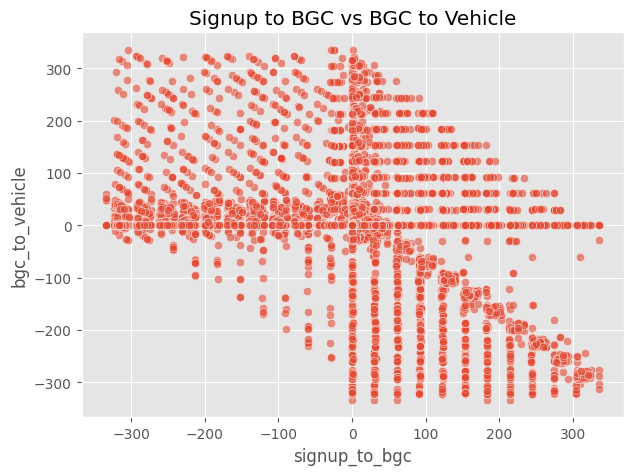

In [78]:
#Scatter Plot

plt.figure(figsize=(7,5))

sns.scatterplot(
    x="signup_to_bgc",
    y="bgc_to_vehicle",
    data=temp,
    alpha=0.6
)

plt.title("Signup to BGC vs BGC to Vehicle")

plt.show()

Insight: Correlation Analysis

We found a Spearman correlation of 0.25 between Signup-to-BGC time and BGC-to-Vehicle Upload time. This indicates a weak-to-moderate positive relationship, suggesting that drivers who progress slowly through the initial onboarding stage also tend to take longer to complete the next stage.

Key Insights:


*   Onboarding Momentum: Drivers who move quickly through one onboarding
stage tend to progress faster through the following stage.
*  Onboarding Momentum: Drivers who move quickly through one onboarding
stage tend to progress faster through the following stage.


*   Early Identification: Signup-to-BGC time can serve as an early indicator of onboarding progress and help identify drivers who may require additional support.
*  Targeted Nudges: Drivers experiencing delays could receive timely reminders or assistance to encourage them to complete the remaining onboarding steps.


*   Long-Tail Delays: The scatter plot shows that most drivers complete both stages within relatively shorter timeframes, while a smaller group takes considerably longer.

In [79]:
#Additional Statistical Summaries

summary = pd.DataFrame({
    "Metric":[
        "Driver Activation Rate",
        "Average Signup→BGC",
        "Average BGC→Vehicle",
        "Average Signup→First Ride"
    ],
    "Value":[
        df["completed_first_ride"].mean()*100,
        df["signup_to_bgc"].mean(),
        df["bgc_to_vehicle"].mean(),
        df["signup_to_firstride"].mean()
    ]
})

summary

,Metric,Value
0,Driver Activation Rate,11.223277
1,Average Signup→BGC,-1.241967
2,Average BGC→Vehicle,0.008595
3,Average Signup→First Ride,-0.513743


**Driver Recruitment Analysis, Predictive Modeling & Business Recommendations**

In [80]:
# Data Preparation

# Select Features

features = [
    "city_name",
    "signup_os",
    "signup_channel",
    "experiment_group",
    "vehicle_make",
    "vehicle_model",
    "vehicle_age",
    "signup_to_bgc",
    "bgc_to_vehicle"
]

X = df[features]

y = df["completed_first_ride"]

In [81]:
# Handle Missing Values

X = X.copy()

categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

for col in categorical_cols:
    X[col] = X[col].fillna("Unknown")

for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

In [82]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)

(54681, 426)


In [83]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [84]:
#Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [85]:
# Predictions

pred = rf.predict(X_test)

prob = rf.predict_proba(X_test)[:, 1]

In [86]:
# Model Evaluation

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision :", precision_score(y_test, pred))
print("Recall :", recall_score(y_test, pred))
print("F1 :", f1_score(y_test, pred))

Accuracy : 0.9143275121148395
Precision : 0.63996138996139
Recall : 0.5403422982885085
F1 : 0.5859478568272205


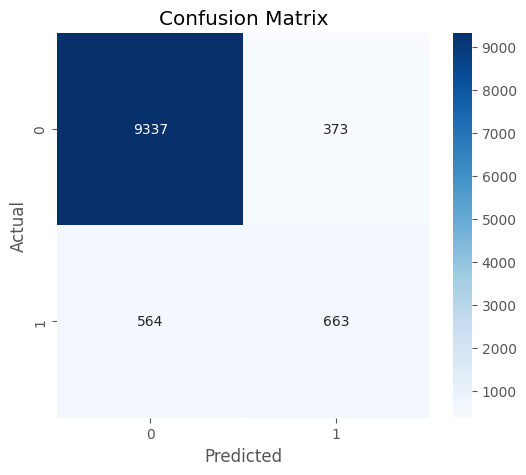

In [87]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [88]:
#Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      9710
           1       0.64      0.54      0.59      1227

    accuracy                           0.91     10937
   macro avg       0.79      0.75      0.77     10937
weighted avg       0.91      0.91      0.91     10937



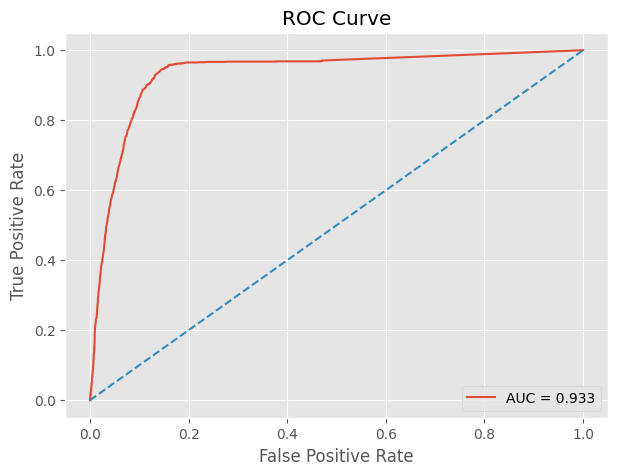

In [89]:
#ROC Curve
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr,tpr,_ = roc_curve(
    y_test,
    prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [90]:
#Feature Importance

#This is the most valuable business insight.

importance = pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
0,vehicle_age,0.173969
1,signup_to_bgc,0.143685
2,bgc_to_vehicle,0.142927
382,vehicle_model_Unknown,0.090594
54,vehicle_make_Unknown,0.079927
11,experiment_group_treatment,0.020453
53,vehicle_make_Toyota,0.019796
10,signup_channel_Referral,0.018298
3,city_name_Strark,0.017101
5,signup_os_ios web,0.013869


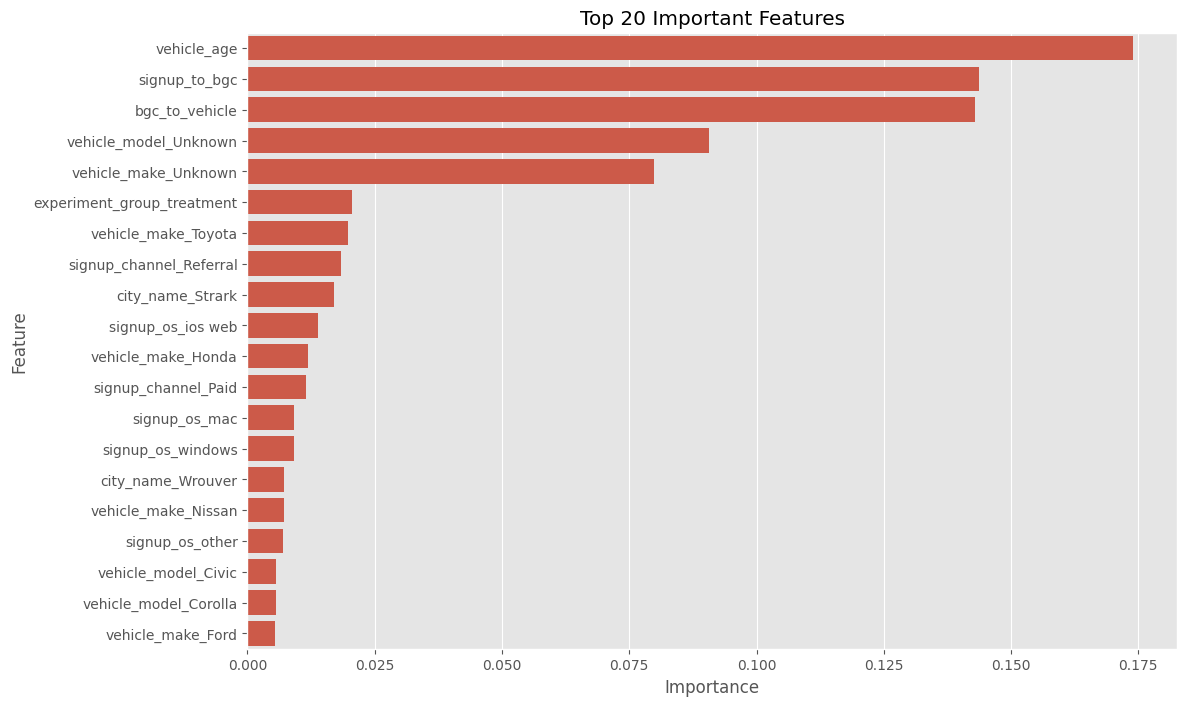

In [91]:
#Visualization

plt.figure(figsize=(12,8))

sns.barplot(

x="Importance",

y="Feature",

data=importance.head(20)

)

plt.title("Top 20 Important Features")

plt.show()

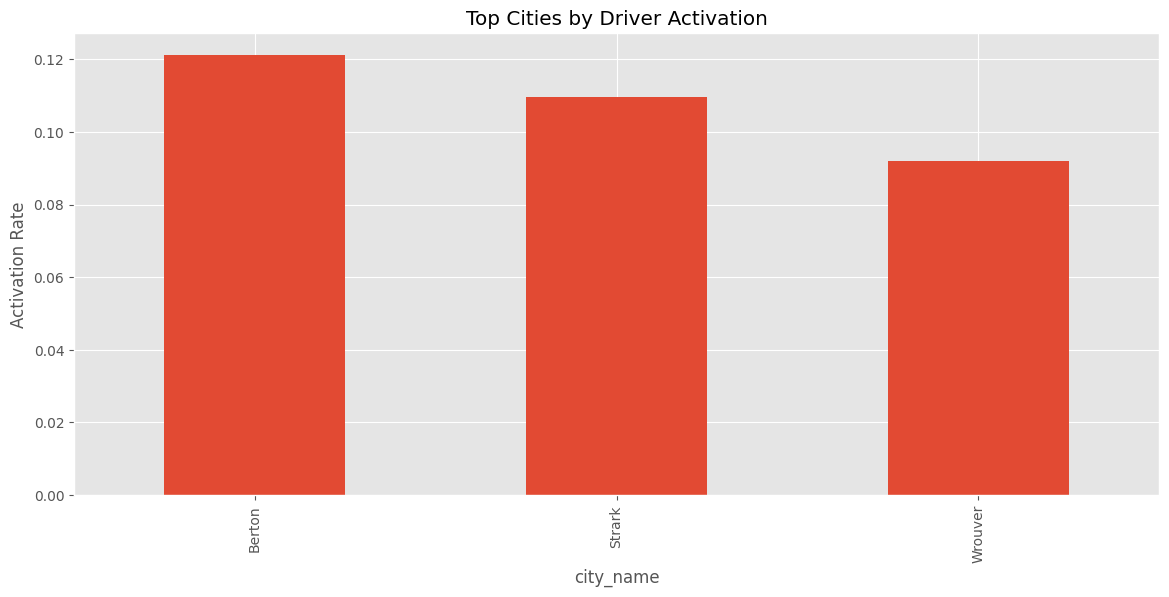

In [92]:
#Additional Business Charts

#Top Cities

city_activation = (
    df.groupby("city_name")
    ["completed_first_ride"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

city_activation.head(15).plot(kind="bar")

plt.ylabel("Activation Rate")

plt.title("Top Cities by Driver Activation")

plt.show()


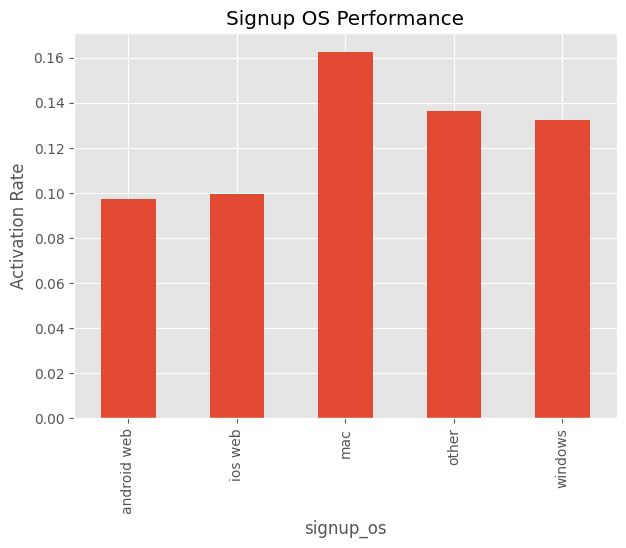

In [93]:
#Signup OS Performance

os_rate = (
    df.groupby("signup_os")
    ["completed_first_ride"]
    .mean()
)

plt.figure(figsize=(7,5))

os_rate.plot(kind="bar")

plt.ylabel("Activation Rate")

plt.title("Signup OS Performance")

plt.show()


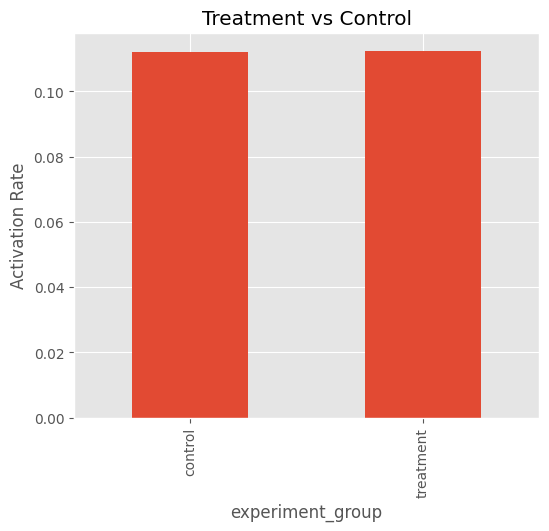

In [94]:
#Experiment Group Performance
exp_rate = (
    df.groupby("experiment_group")
    ["completed_first_ride"]
    .mean()
)

plt.figure(figsize=(6,5))

exp_rate.plot(kind="bar")

plt.ylabel("Activation Rate")

plt.title("Treatment vs Control")

plt.show()

In [95]:
#Final Dashboard Table

dashboard = pd.DataFrame({

"Metric":[

"Driver Activation Rate",

"Average Signup→BGC",

"Average BGC→Vehicle",

"Average Signup→First Ride",

"Treatment Activation",

"Control Activation"

],

"Value":[

round(df.completed_first_ride.mean()*100,2),

round(df.signup_to_bgc.mean(),2),

round(df.bgc_to_vehicle.mean(),2),

round(df.signup_to_firstride.mean(),2),

round(
df[df.experiment_group=="treatment"]
.completed_first_ride.mean()*100,
2
),

round(
df[df.experiment_group=="control"]
.completed_first_ride.mean()*100,
2
)

]

})

dashboard

,Metric,Value
0,Driver Activation Rate,11.22
1,Average Signup→BGC,-1.24
2,Average BGC→Vehicle,0.01
3,Average Signup→First Ride,-0.51
4,Treatment Activation,11.24
5,Control Activation,11.21
